# IDENTIFICACIÓN NADADORES EN PISCINA - EXPLORACIÓN INICIAL DE COLORES PARA MÁSCARA DEL FONDO

Juan David Hurtado Molano

Laura Sofía Salamanca Barrera

In [61]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Vista superior

En la vista superior de la piscina se encuentran un panorama completo de la piscina, los carriles bien divididos y los nadadores no se sobrelapan en la imagen.

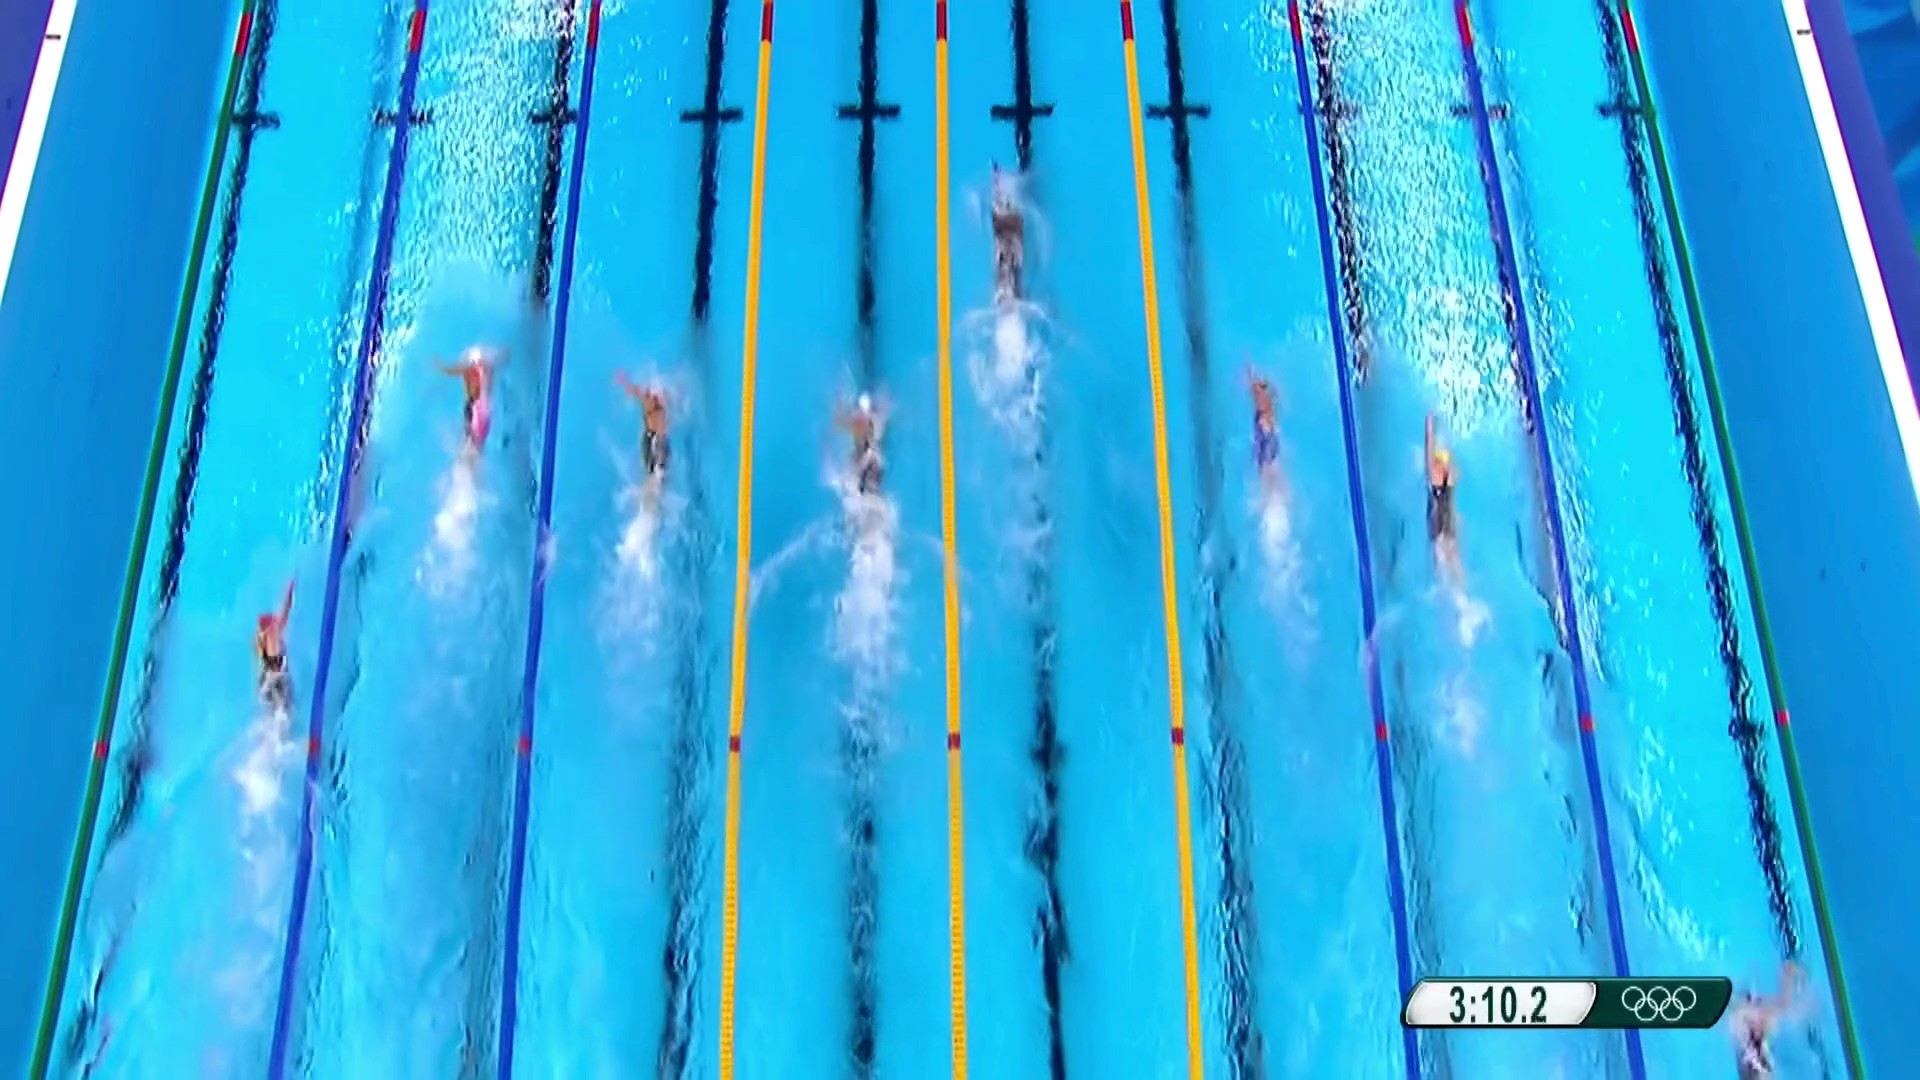

Características de la imagen a tener en cuenta:



*   La piscina tiene un color azulado - cian, el fondo de la piscina es constante y solo tiene 4 casos donde difiere:


    1.   Nadadores
    2.   Burbujas
    3.   Líneas de fondo de la piscina (líneas guía)
    4.   Corcheras (lo que divide los carriles)

*   Las corcheras, en este caso, tienen 3 colores diferentes: Amarillo (las de  la mitad), azul, y verde (las de los bordes). También tienen pedacitos rojos. Eso puede ayudar a la identificación las corcheras y de los carriles. Además siempre son lineas rectas.

*   Las burbujas generan una sensación de color blanco y distorsión.

*   La piscina en general ve que tiene un efecto brillante, o el efecto reflejo del agua. En muchos casos el brillo que muestra un carril puede diferenciar entre lo que es agua y lo que no.

*   Ese contraste del brillo aporta información para identificar las corcheras porque esas mantienen un color y un brillo constante.

*   Las corcheras pueden llegar a parecerse mucho a las líneas guía de la piscina, lo que las llega a diferenciar es la saturación o el color (las del fondo son mucho más oscuras).





### Exploración de espacios de colorimetría

In [62]:
image = cv2.cvtColor(cv2.imread('C:\ProcesamientoImagenesNadadores\data\ejemplos\IS.jpg'), cv2.COLOR_BGR2RGB)
print(image.shape)
image = cv2.resize(image, (512,512))
print(image.shape)

(1080, 1920, 3)
(512, 512, 3)


<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\laura\AppData\Local\Temp\ipykernel_29944\1854248871.py:1: SyntaxWarning: invalid escape sequence '\P'
  image = cv2.cvtColor(cv2.imread('C:\ProcesamientoImagenesNadadores\data\ejemplos\IS.jpg'), cv2.COLOR_BGR2RGB)


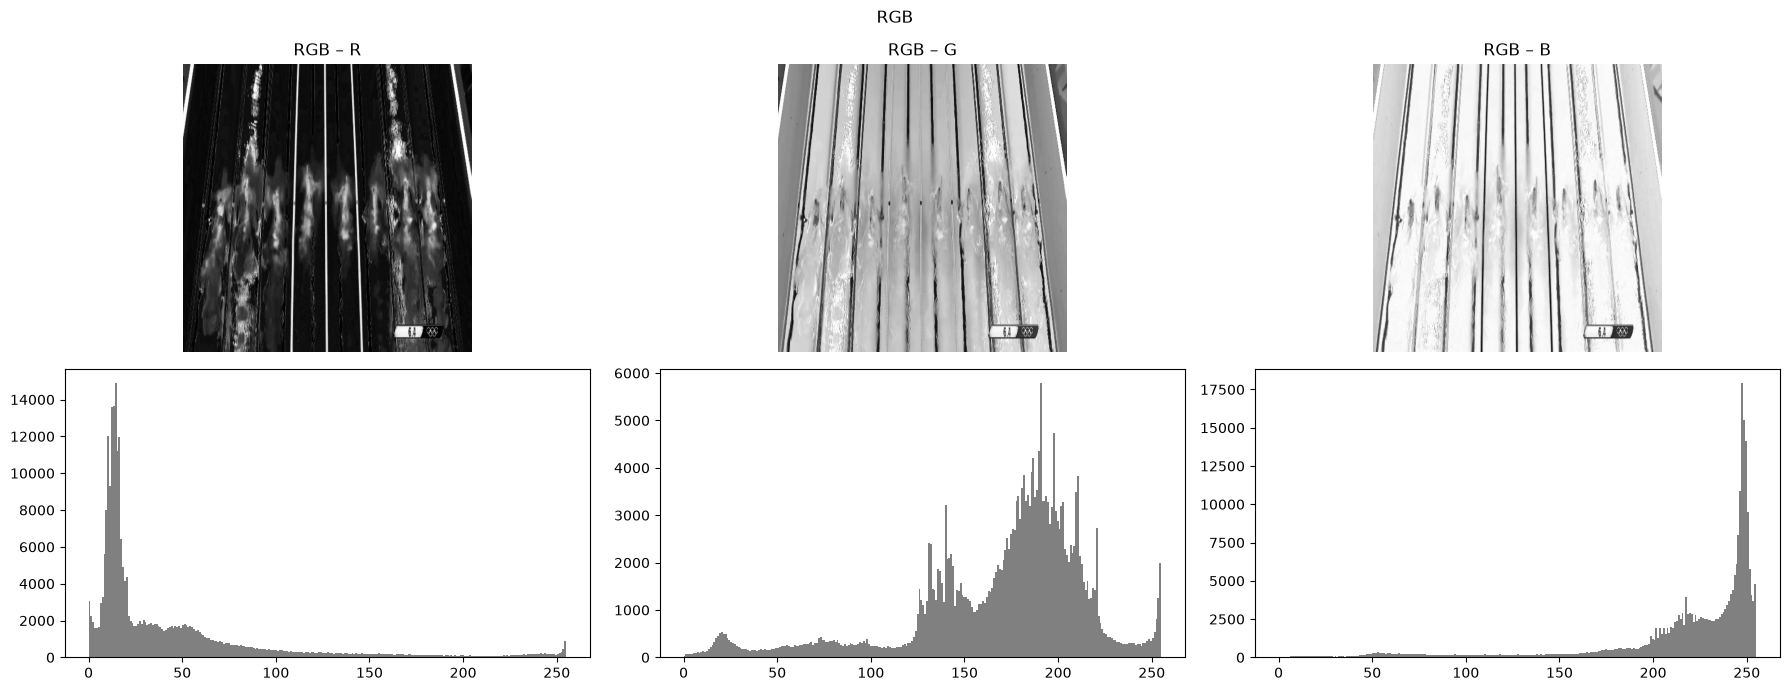

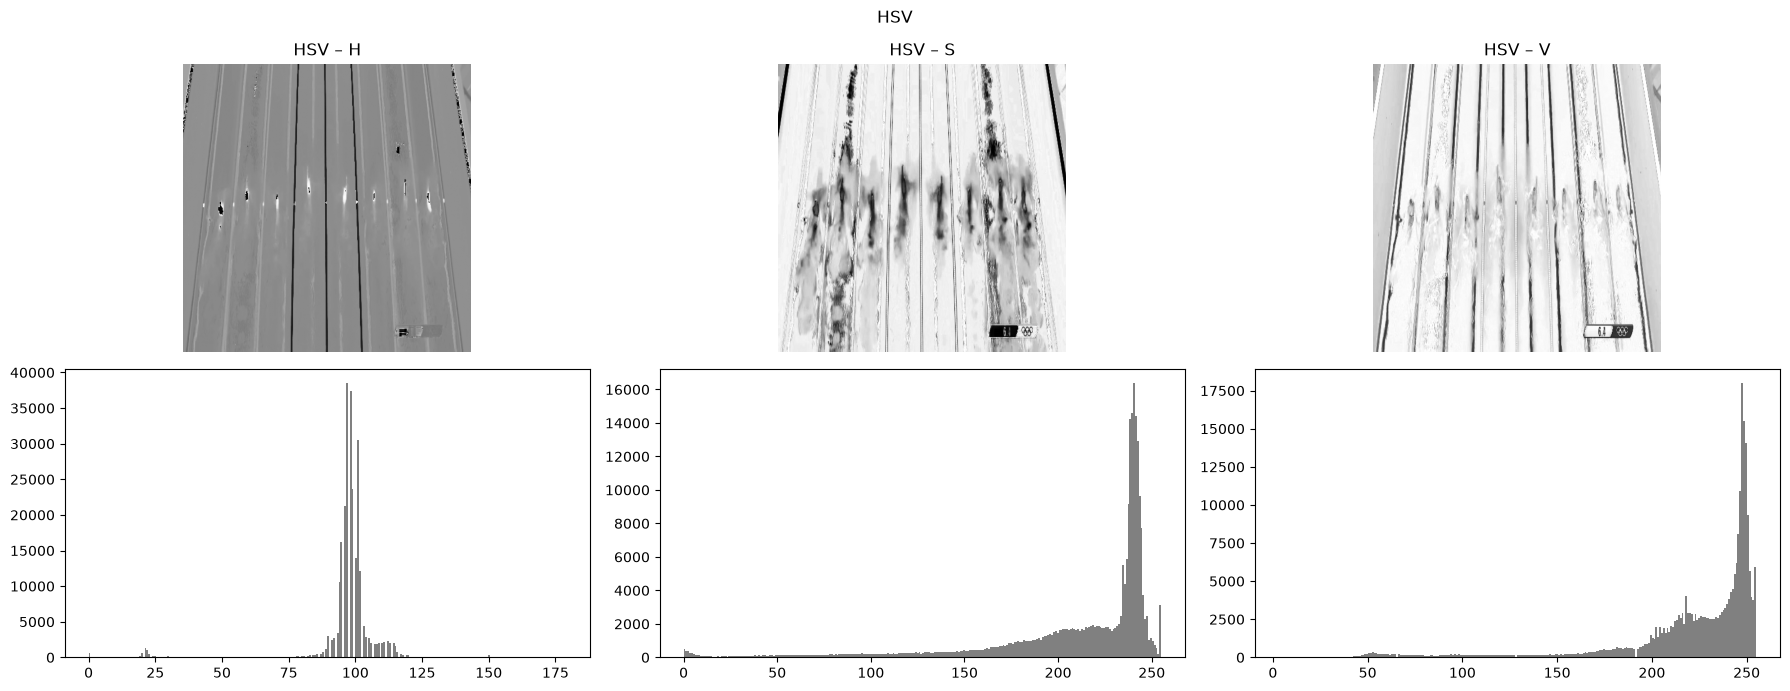

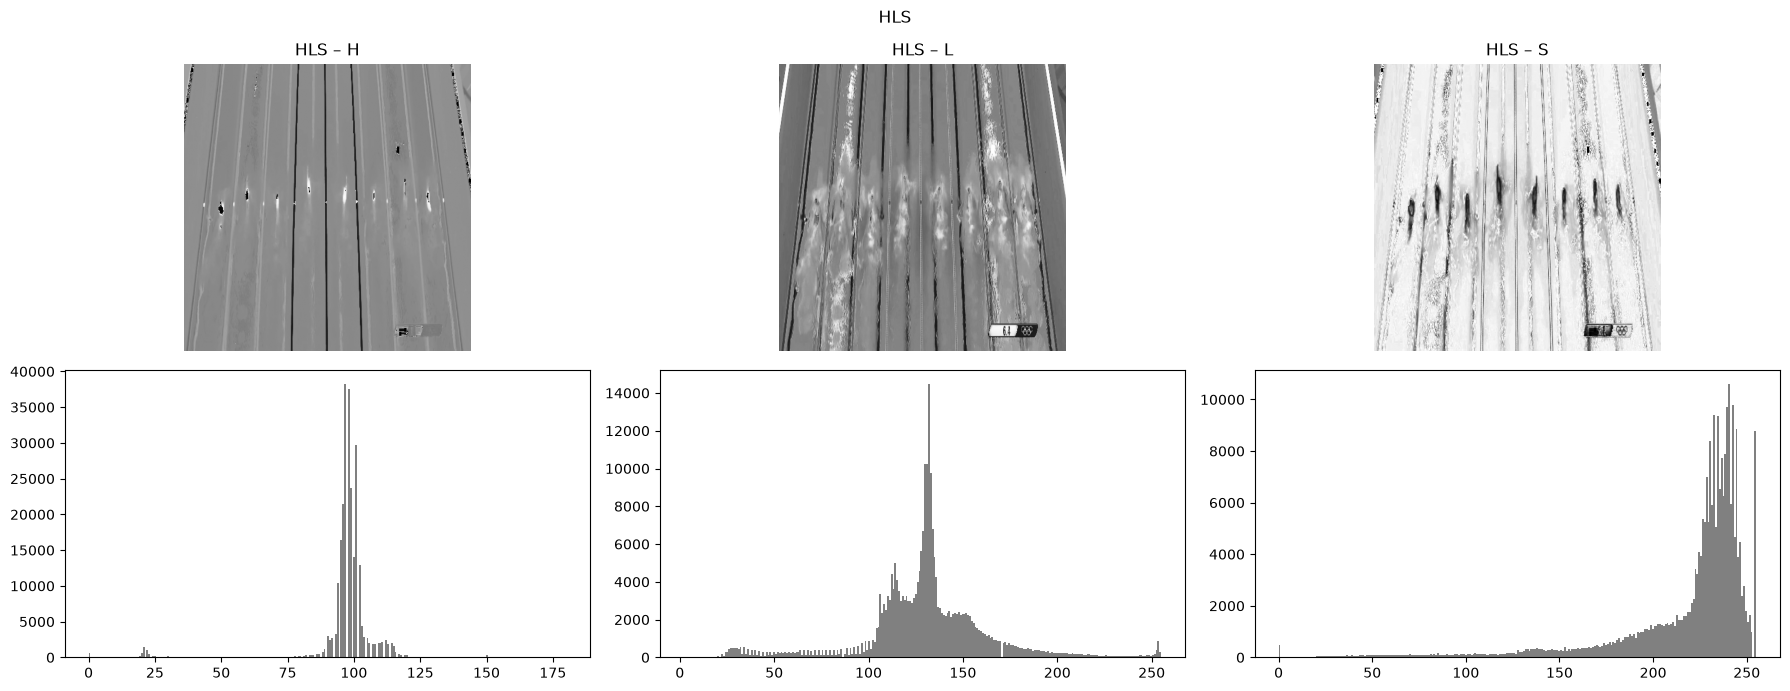

In [63]:
#LAB y YCrCb se ignoran porque no aportan nada.
espacios = {
    'RGB':   (image, ['R', 'G', 'B']),
    'HSV':   (cv2.cvtColor(image, cv2.COLOR_RGB2HSV), ['H', 'S', 'V']),
    'HLS':   (cv2.cvtColor(image, cv2.COLOR_RGB2HLS), ['H', 'L', 'S'])
}

for nombre, (im, canales) in espacios.items():
    fig, ax = plt.subplots(2, 3, figsize=(18, 7))
    for i, c in enumerate(canales):
        ax[0, i].imshow(im[..., i], cmap='gray'); ax[0, i].set_title(f'{nombre} – {c}'); ax[0, i].axis('off')
        ax[1, i].hist(im[..., i].ravel(), bins=256, color='gray')
    plt.suptitle(nombre); plt.tight_layout(); plt.show()

La mayoría de la imagen es piscina, por lo tanto, los píxeles relacionados con la piscina deben ser muy similares (eso implica que el histograma se debe concentrar en una media y no debe tener colas tan alargadas).



*   RGB: en este caso si existen comportamientos inusuales, sobre todo en el espacio de color G (green). Rojo casi no hay en la imagen, por lo que la cola esta a la izquierda. Azul si se presenta mucho por el color del agua/piscina, por lo que tiene cola a la derecha. Pero el verde no se concentra ni a la izquierda ni a la derecha, por lo que no puede hacer una separación 'suficiente' en ese espacio.
*   HSV y HLS:
   

    *   H (tono/color): este es el que más resalta de todos, pues se ve que la curva esta MUY concentrada en el centro, que corresponde al color azul/cyan. Ese tipo de discriminación es la que buscamos. Diferencia muy bien el fondo.
    *   S (HSV): el histograma no es tan centrado y presenta ruido, esto puede ser consecuencia del brillo que refleja la piscina.
    *   S (HLS): a diferencia de S - HSV, este histograma esta más a la derecha. No presenta de forma notoria el reflejo de la piscina. Sin embargo, no logra diferenciar de todo el fondo/las lineas de fondo y las corcheras.
    *   L (HLS): si se ve mucho el efecto del brillo del carril 2 y 8. Eso hace qu eno se diferencie bien el fondo.
    *   V (HSV): El agua queda blanca y uniforme (y tiene un pico en el histograma cercano a 250), de esta forma, lo que es más oscuro resalta más (nadadores, corcheras, líneas guías)

Con esto, el espacio a utilizar sería el HSV:


*   Contra RGB, Lab y YCrCb: en HSV el fondo queda en un solo canal, con un pico estrecho y separado. En RGB está repartido en tres canales, y en Lab y YCrCb el pico es más ancho y el color queda dividido en dos canales.
*   Contra HLS: el tono es el mismo, pero S y V de HSV separan mejor las clases difíciles, es decir, las burbujas y las líneas guía.




### Separación del fondo

Según el histograma de HSV, el tono de la piscina puede encontrarse entre 80 y 110. Se utiliza este valor inicial y a partir de ahí se experimenta.

Además es importante mencionar que los tonos principales en la imagen son:



*   Corchera verde: 87 aprox
*   Piscina agua: 98 aprox
*   Corchera amarilla: 44 aprox
*   Corchera azul: 112
*   Lineas azules guía: 100-110


Esto ya nos da el primer diagnostico: la corchera amarilla se va a segmentar solo por tono. Pero los demás elementos toca hacerle más tratamiento.



In [64]:
hsv = (cv2.cvtColor(image, cv2.COLOR_RGB2HSV))

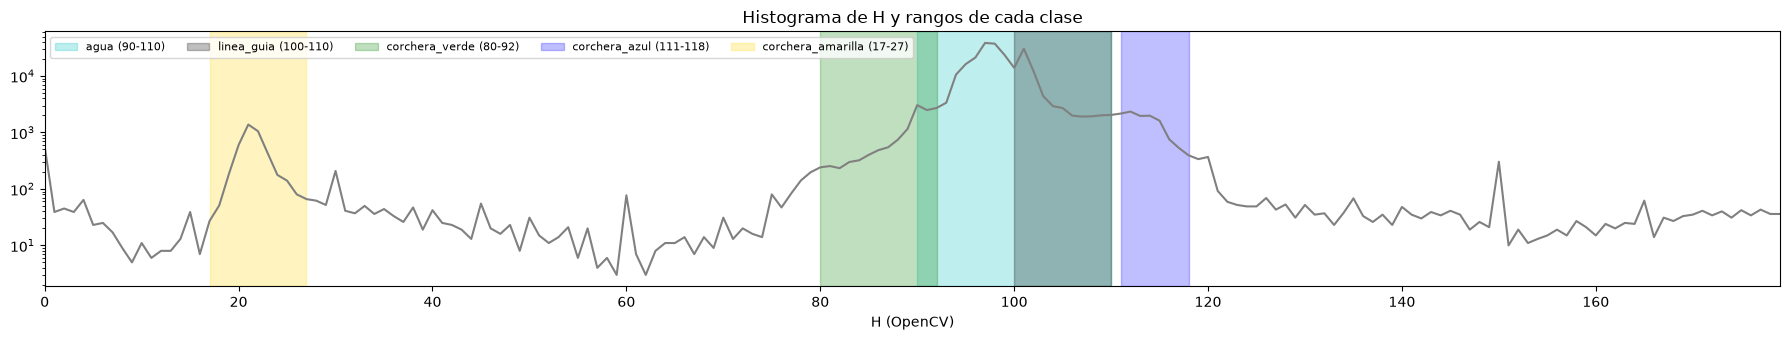

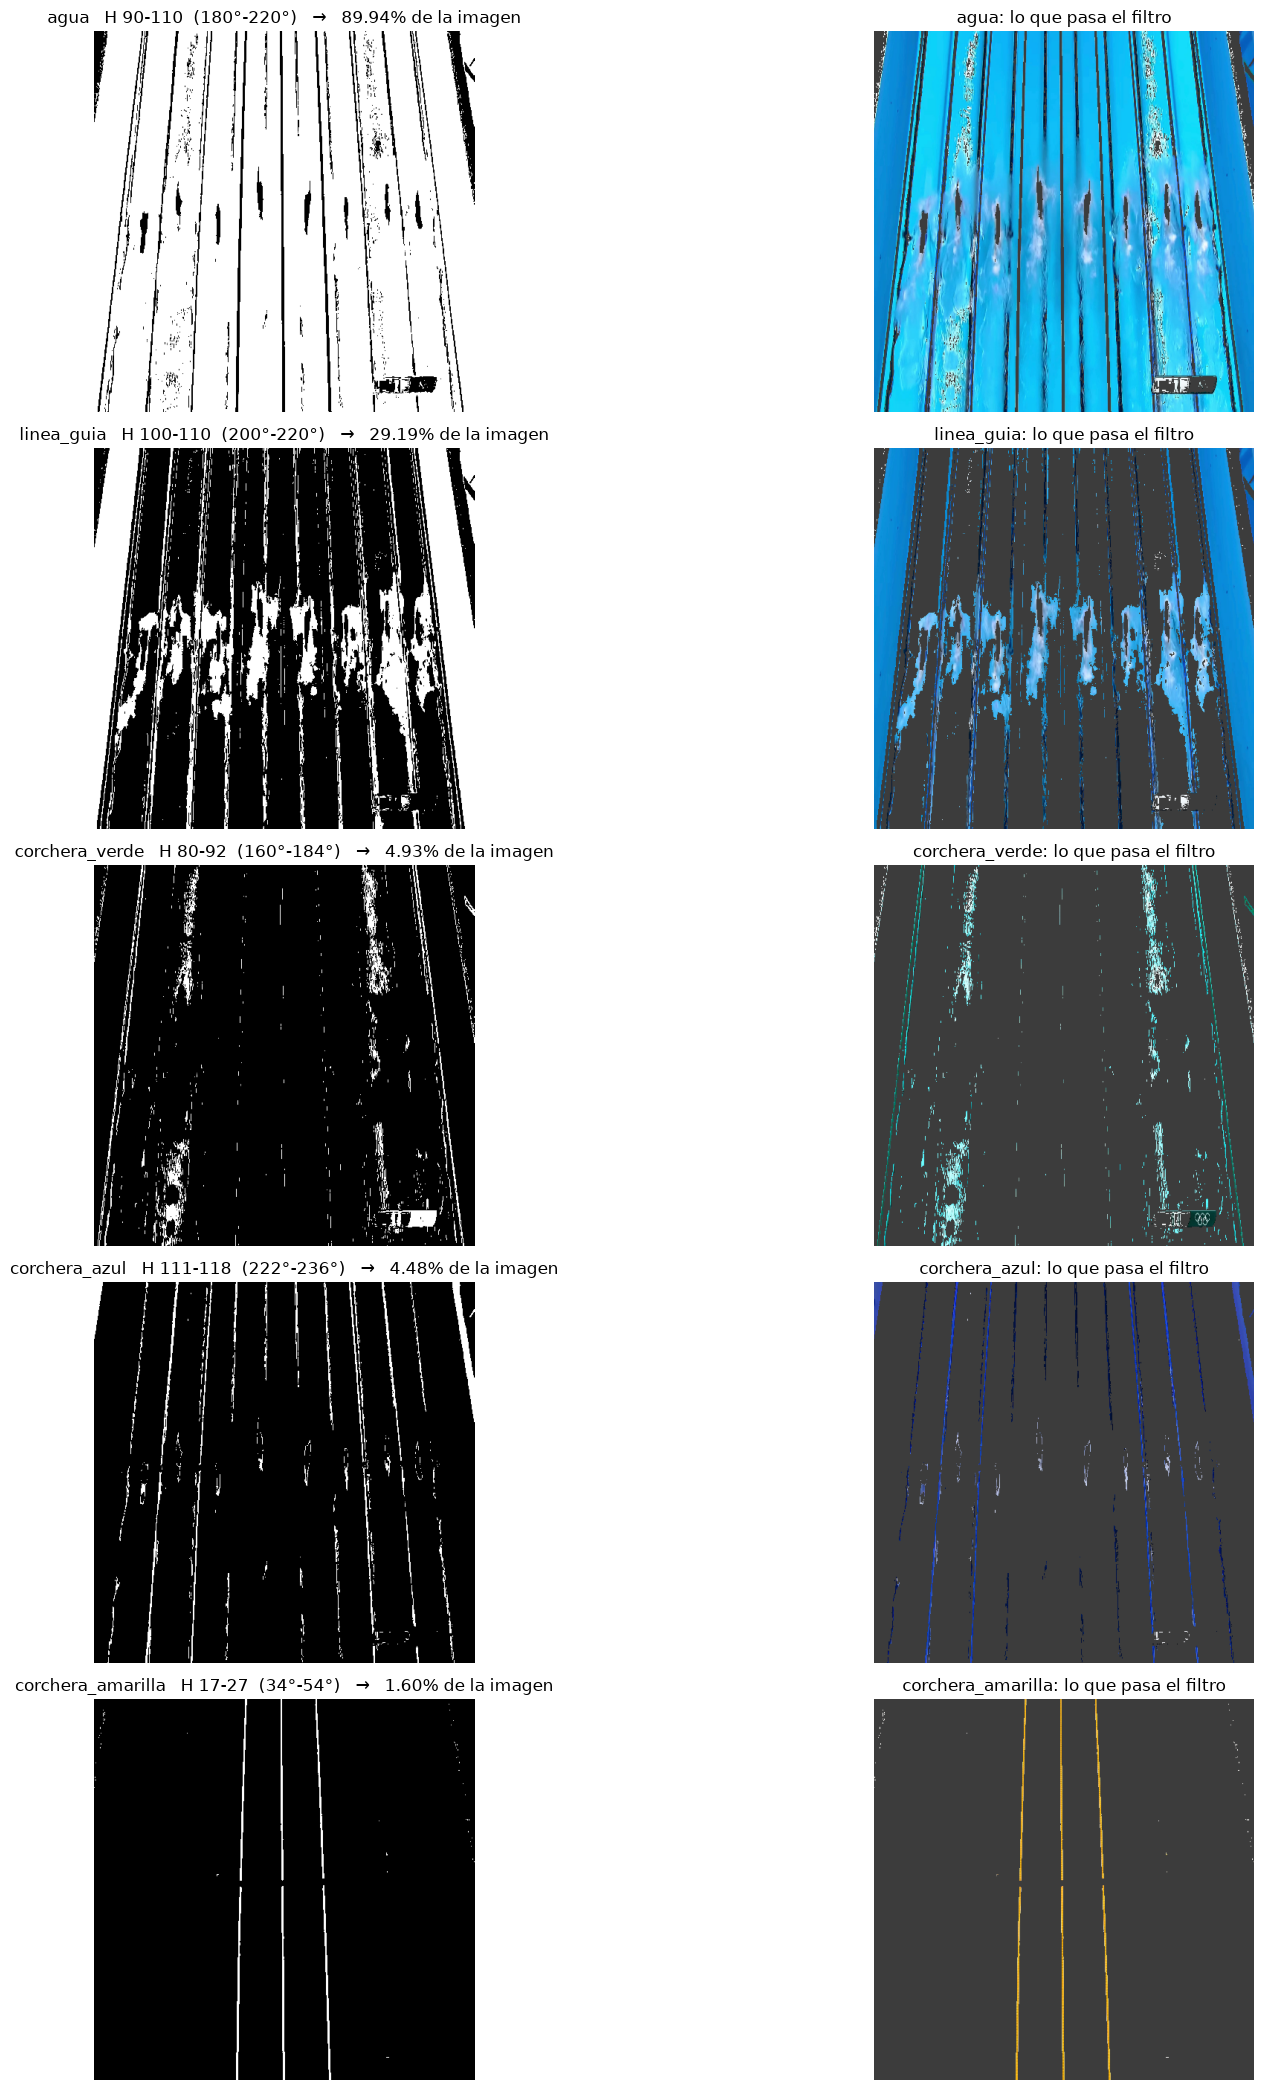

In [65]:
RANGOS = {
    'agua':              (90, 110),
    'linea_guia':        (100, 110),
    'corchera_verde':    (80, 92),
    'corchera_azul':     (111, 118),
    'corchera_amarilla': (17, 27),
}
COLORES = {'agua': 'c',
           'linea_guia': 'k',
           'corchera_verde': 'g',
           'corchera_azul': 'b',
           'corchera_amarilla': 'gold'
}

H = hsv[..., 0]
mascaras = {c: cv2.inRange(H, h0, h1) for c, (h0, h1) in RANGOS.items()}

# 1) Histograma de H con todos los rangos:
hist_H = cv2.calcHist([hsv], [0], None, [180], [0, 180]).ravel()
fig, ax = plt.subplots(figsize=(18, 3.5))
ax.plot(hist_H, color='gray')
for c, (h0, h1) in RANGOS.items():
    ax.axvspan(h0, h1, alpha=.25, color=COLORES[c], label=f'{c} ({h0}-{h1})')
ax.set_yscale('log'); ax.set_xlim(0, 179); ax.set_xlabel('H (OpenCV)')
ax.legend(fontsize=8, ncol=5, loc='upper left'); ax.set_title('Histograma de H y rangos de cada clase')
plt.tight_layout(); plt.show()

# 2) Todas las máscaras en una sola figura: máscara
fondo_gris = np.full_like(image, 60)             
fig, ax = plt.subplots(len(mascaras), 2, figsize=(20, 4.2 * len(mascaras)))
for fila, (c, m) in zip(ax, mascaras.items()):
    h0, h1 = RANGOS[c]
    fila[0].imshow(m, cmap='gray')
    fila[0].set_title(f'{c}   H {h0}-{h1}  ({h0*2}°-{h1*2}°)   →   {m.mean()/2.55:.2f}% de la imagen')
    fila[1].imshow(np.where(m[..., None] > 0, image, fondo_gris))
    fila[1].set_title(f'{c}: lo que pasa el filtro')
    for a in fila: a.axis('off')
plt.tight_layout(); plt.show()




*   El tono en definitiva es una muy buena opción para separar el fondo de los objetos. Como se ve en la primera imagen, la mascara generada deja pasar la mayoría de píxeles correspondientes al agua y a las líneas de fondo; esto es lo que queremos ignorar.
*   La mascara para la corchera amarilla también es buena tomando en cuenta solo el tono.
*   En las otras mascaras (corcheras azules y verdes), aunque los colores si nos pueden dar idea de como esta la segmentación, no es suficiente porque se presenta mucho ruido. Entonces: para identificar nadadores y corcheras, debemos trabajar con algo más alla del tono.

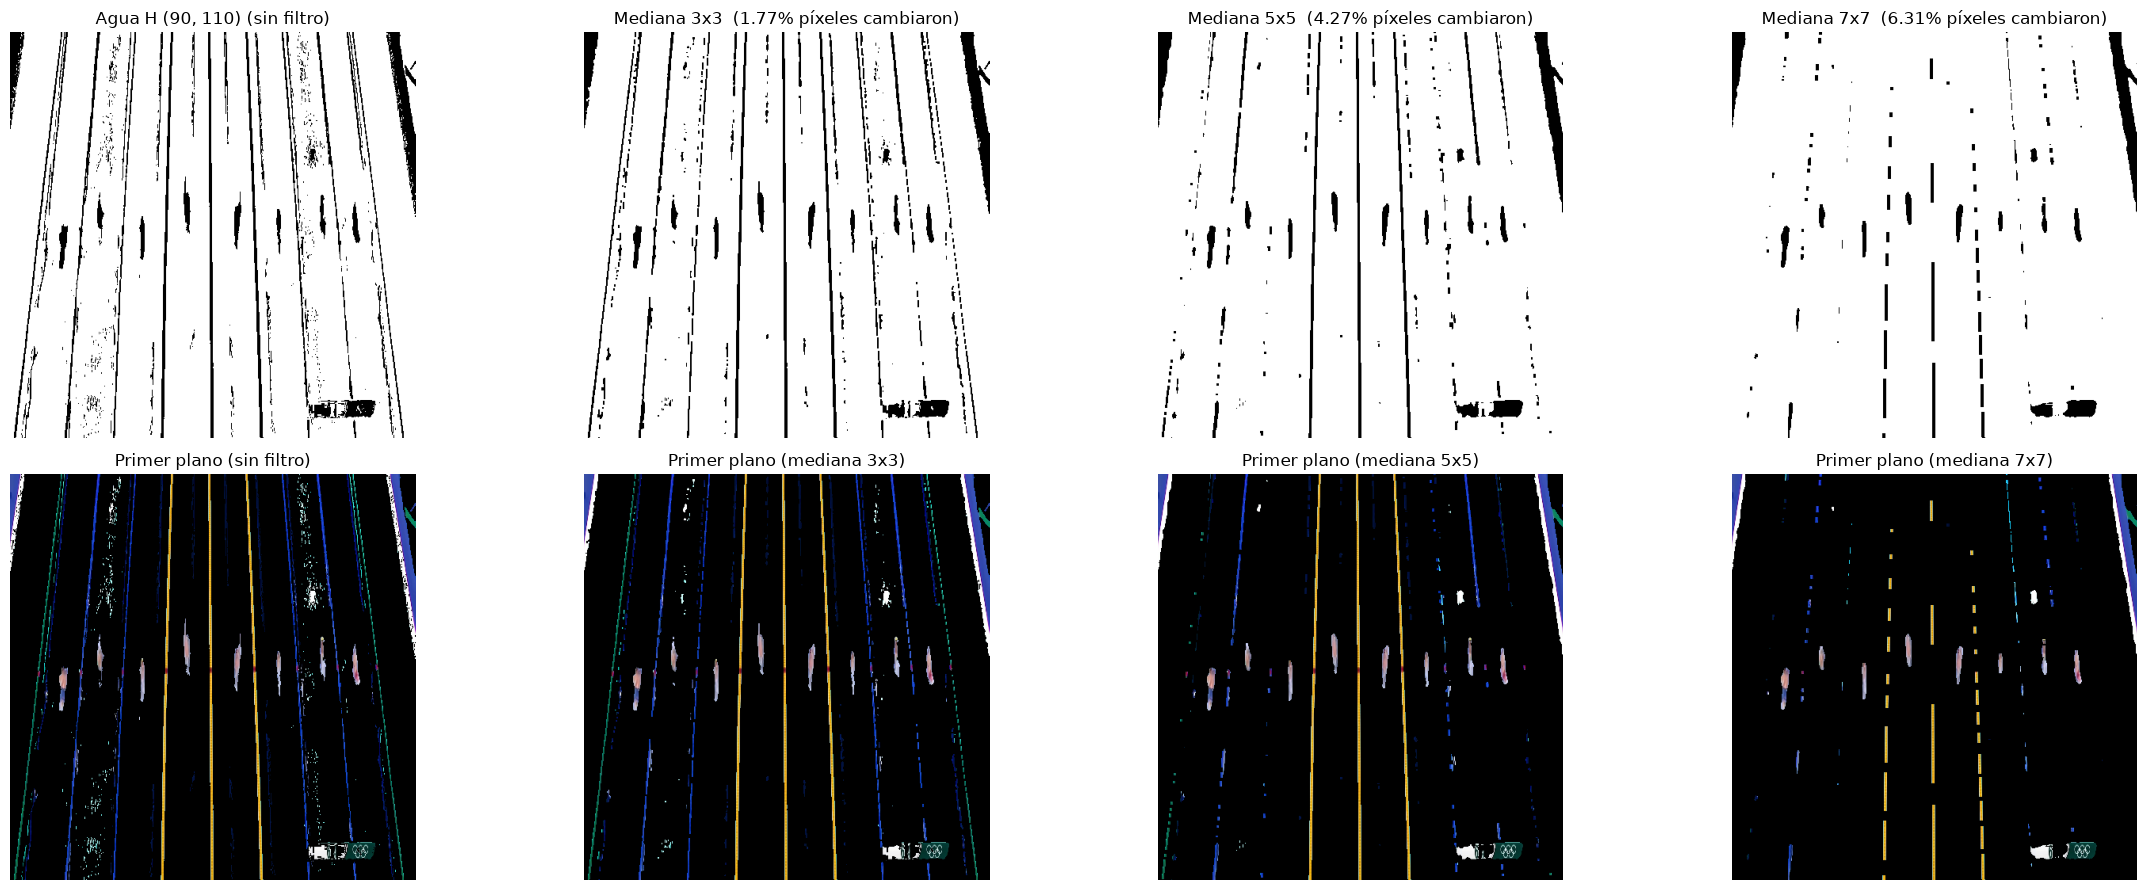

In [66]:
H_AGUA = (90, 110)                        

agua = cv2.inRange(hsv[..., 0], *H_AGUA)   

tamanos = [3, 5, 7]
agua_filtrada = {k: cv2.medianBlur(agua, k) for k in tamanos}

fig, ax = plt.subplots(2, 4, figsize=(24, 9))
ax[0, 0].imshow(agua, cmap='gray'); ax[0, 0].set_title(f'Agua H {H_AGUA} (sin filtro)')
ax[1, 0].imshow(cv2.bitwise_and(image, image, mask=255 - agua)); ax[1, 0].set_title('Primer plano (sin filtro)')
for i, k in enumerate(tamanos, start=1):
    m = agua_filtrada[k]
    cambiados = (m != agua).mean() * 100
    ax[0, i].imshow(m, cmap='gray'); ax[0, i].set_title(f'Mediana {k}x{k}  ({cambiados:.2f}% píxeles cambiaron)')
    ax[1, i].imshow(cv2.bitwise_and(image, image, mask=255 - m)); ax[1, i].set_title(f'Primer plano (mediana {k}x{k})')
for a in ax.ravel(): a.axis('off')
plt.tight_layout(); plt.show()

Con la máscara de agua fija en H 90-110 se prueba una mediana cuadrada de 3x3, 5x5 y 7x7. La idea es quitar el ruido de burbujas y de brillo sin volver a tocar el tono.

*   La de 3x3 limpia puntos sueltos y casi no mueve el borde del nadador.
*   La de 5x5, y más la de 7x7, cierra más huecos, pero se come al nadador y a las corcheras: la ventana es igual de ancha que de alta y mira para todos lados.

La mediana sola no alcanza. Hace falta un filtro que siga la dirección de los carriles en vez de suavizar en todas las direcciones. Eso se prueba en la celda siguiente.

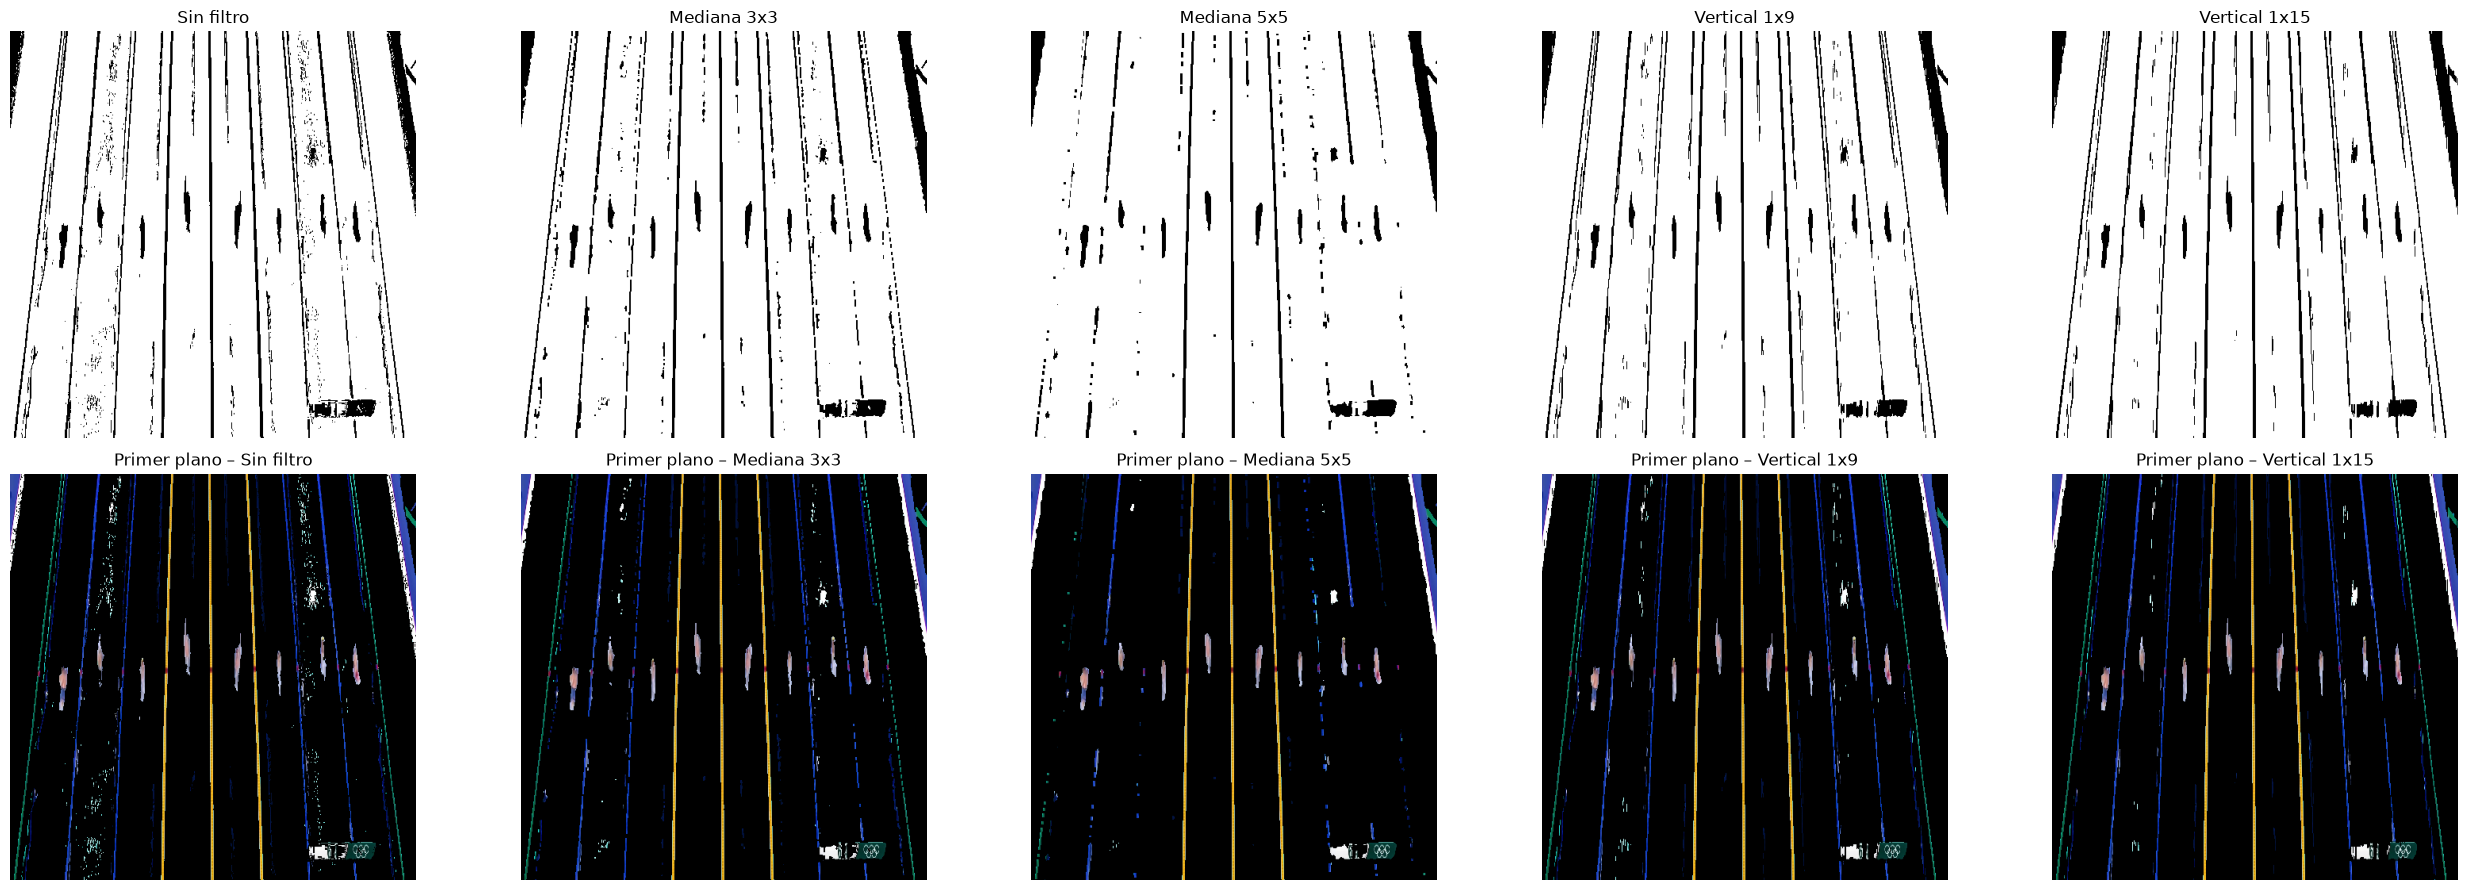

In [67]:
agua = cv2.inRange(hsv[..., 0], 90, 110)

def votacion(mascara, ancho, alto):
    """Promedio en una ventana ancho x alto y umbral 0.5 = votación de mayoría (como la mediana)."""
    return ((cv2.blur(mascara, (ancho, alto)) > 127) * 255).astype(np.uint8)

versiones = {
    'Sin filtro':          agua,
    'Mediana 3x3':         cv2.medianBlur(agua, 3),
    'Mediana 5x5':         cv2.medianBlur(agua, 5),
    'Vertical 1x9':        votacion(agua, 1, 9),
    'Vertical 1x15':       votacion(agua, 1, 15),
}

fig, ax = plt.subplots(2, len(versiones), figsize=(26, 9))
for i, (nombre, m) in enumerate(versiones.items()):
    ax[0, i].imshow(m, cmap='gray'); ax[0, i].set_title(nombre)
    ax[1, i].imshow(cv2.bitwise_and(image, image, mask=255 - m)); ax[1, i].set_title(f'Primer plano – {nombre}')
for a in ax.ravel(): a.axis('off')
plt.tight_layout(); plt.show()

La mediana cuadrada mira para todos lados, así que quita puntos sueltos pero también se come el borde del nadador y de las corcheras. La ventana vertical solo vota hacia arriba y hacia abajo: un píxel queda como agua si la mayoría de esa columna corta también es agua.

*   La mediana 3x3 cambia poco. La 5x5 ya suaviza de más y desdibuja el primer plano.
*   La ventana 1x9 todavía deja huecos de burbuja y de brillo. La 1x15 los cierra mejor sin borrar al nadador.

Por eso se sigue con la votación vertical 1x15. La mediana cuadrada queda solo como un filtro fino, no como el filtro principal.

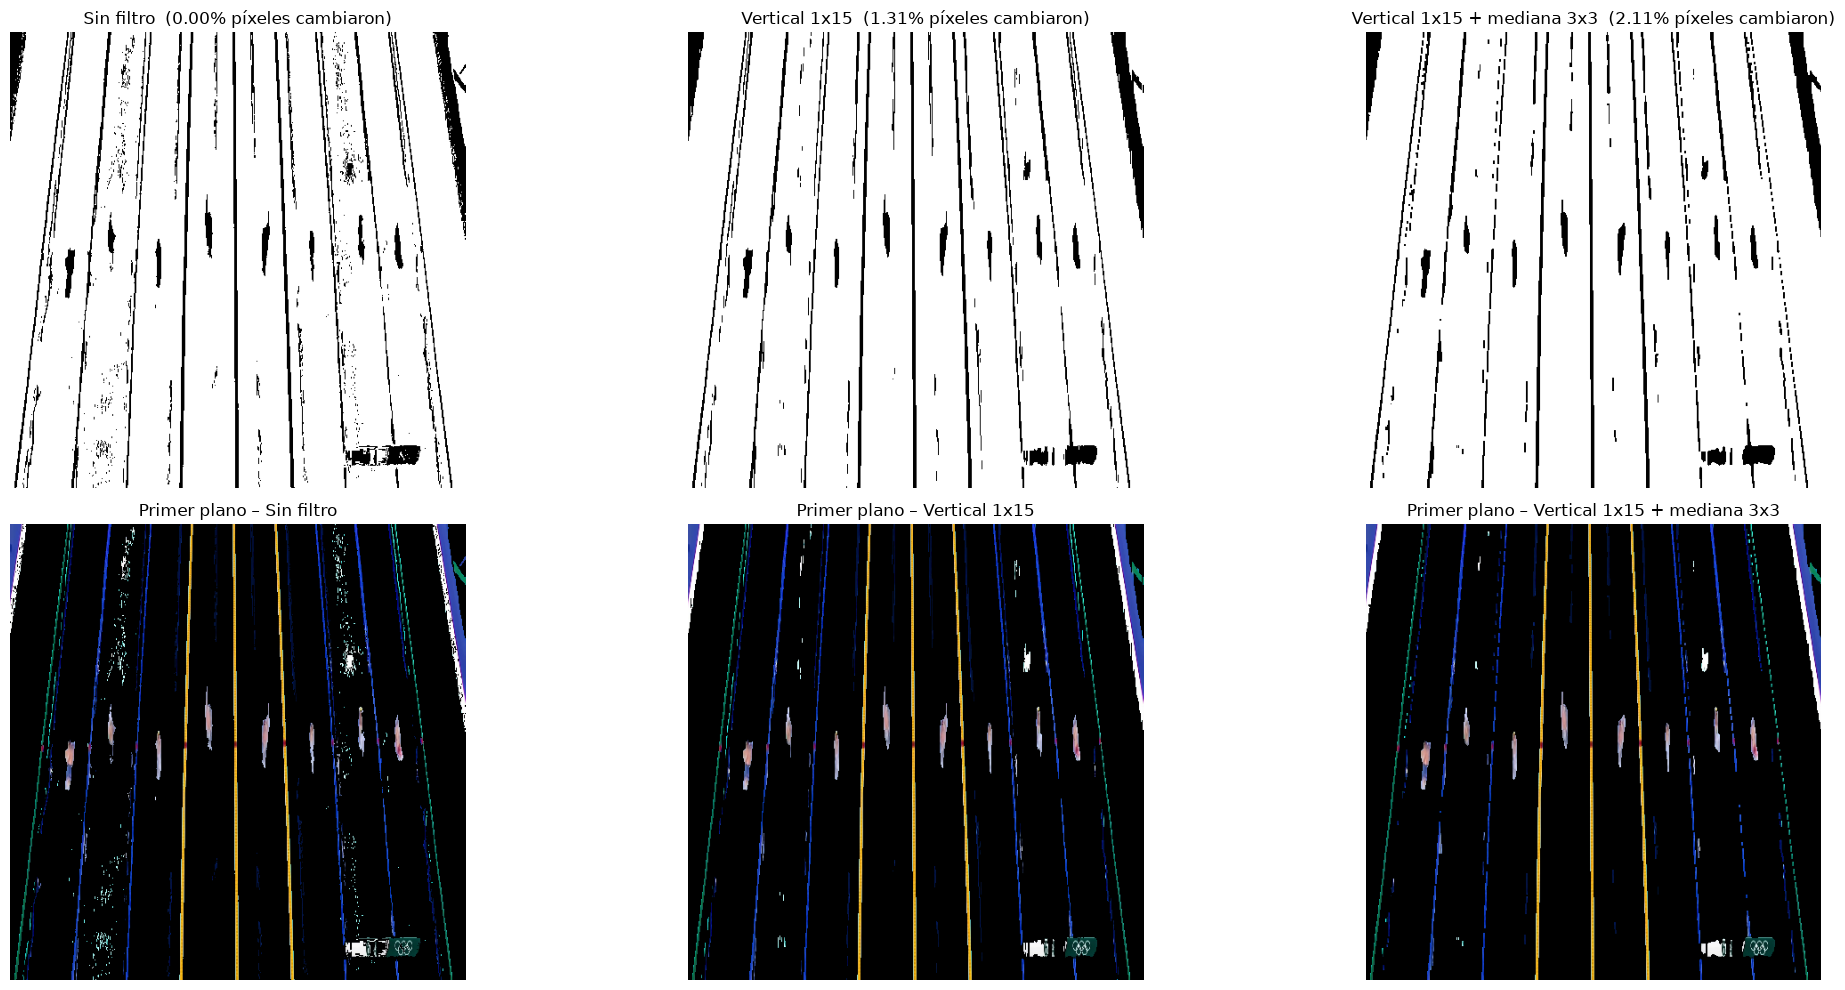

In [68]:
agua = cv2.inRange(hsv[..., 0], 90, 110)

versiones = {
    'Sin filtro':                  agua,
    'Vertical 1x15':               votacion(agua, 1, 15),
    'Vertical 1x15 + mediana 3x3': cv2.medianBlur(votacion(agua, 1, 15), 3),
}

fig, ax = plt.subplots(2, len(versiones), figsize=(22, 10))
for i, (nombre, m) in enumerate(versiones.items()):
    cambiados = (m != agua).mean() * 100
    ax[0, i].imshow(m, cmap='gray')
    ax[0, i].set_title(f'{nombre}  ({cambiados:.2f}% píxeles cambiaron)')
    ax[1, i].imshow(cv2.bitwise_and(image, image, mask=255 - m))
    ax[1, i].set_title(f'Primer plano – {nombre}')
for a in ax.ravel(): a.axis('off')
plt.tight_layout(); plt.show()

La ventana 1x15 no ve a los vecinos de los lados, así que puede quedar ruido en horizontal. Una mediana 3x3 después de la votación quita esos puntos sin deshacer lo que el filtro vertical ya cerró.

*   La vertical 1x15 sola ya separa la mayor parte del agua.
*   Sumarle la mediana 3x3 cambia pocos píxeles y deja la máscara más limpia.
*   Esa combinación es la que se usa de aquí en adelante.

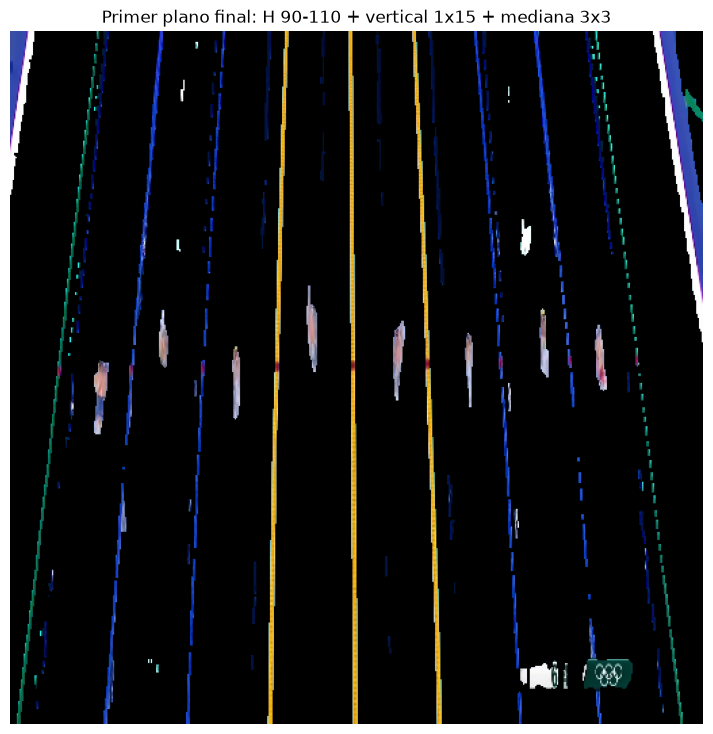

In [69]:
agua = cv2.inRange(hsv[..., 0], 90, 110)
combinado = cv2.medianBlur(votacion(agua, 1, 15), 3)   # vertical 1x15 + mediana 3x3

primer_plano = cv2.bitwise_and(image, image, mask=255 - combinado)

plt.figure(figsize=(16, 9))
plt.imshow(primer_plano)
plt.title('Primer plano final: H 90-110 + vertical 1x15 + mediana 3x3')
plt.axis('off')
plt.show()

Máscara de agua de la vista superior: tono H entre 90 y 110, votación vertical 1x15 y mediana 3x3.

Lo negro es agua (lo que se ignora). Lo que se ve en color es lo que no pasó ese filtro: nadadores, corcheras y lo que el tono no clasificó como piscina.

## Vista lateral piscina (ILP)

Misma exploración que la vista superior, ahora sobre la imagen de ejemplo ILP. Los rangos, los filtros y este texto son el punto de partida: hay que ajustarlos a esta vista.

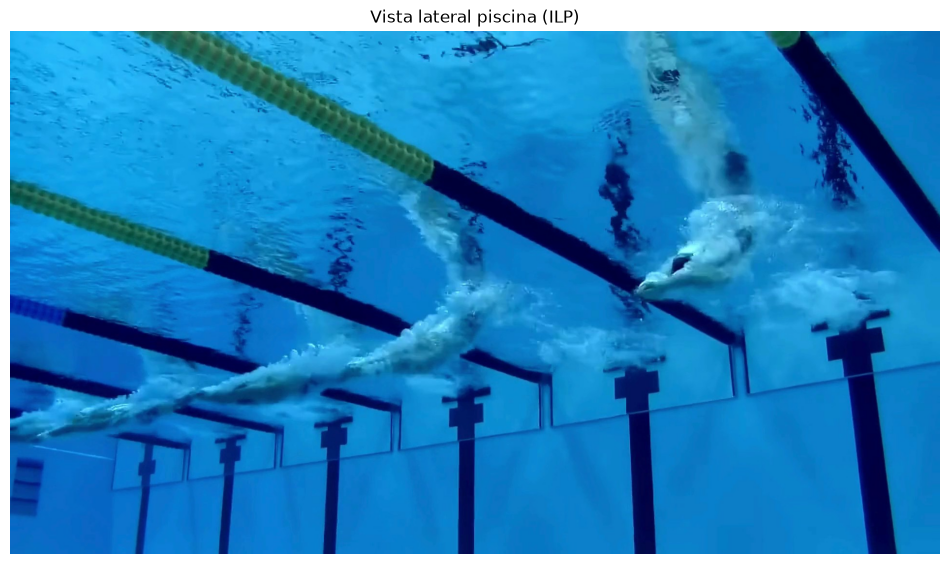

In [70]:
ejemplo_ilp = cv2.cvtColor(cv2.imread(r'C:\ProcesamientoImagenesNadadores\data\ejemplos\ILP.jpg'), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 7))
plt.imshow(ejemplo_ilp)
plt.title('Vista lateral piscina (ILP)')
plt.axis('off')
plt.show()

Características de la imagen a tener en cuenta:



*   La piscina tiene un color azulado - cian. Hay casos donde difiere el color


    1.   Nadadores
    2.   Burbujas
    3.   Líneas de fondo de la piscina (líneas guía)
    4.   Corcheras (lo que divide los carriles)

*   Las corcheras, en este caso, tienen varios colores, aunque no se ven todas en la misma imagen, las corcheras presentan pedazos con colores diferentes. Tienen 3 colores distintos: Amarillo y azul (acá las verdes no se notan porque las verdes son de los bordes). También tienen pedacitos rojos. Son siempre lineas rectas pero no siempre se sabra la dirección de ellas (diagonal u horizontal)

*   Las burbujas generan una sensación de color blanco y distorsión.

*   En esta toma se ve que la piscina genera un reflejo, lo cual será importante en el analisis. 

*   Ese contraste del brillo aporta información para diferenciar lo que que son las corcheras. Las corcheras NO producen brillo y son mas opacas.

*   Las corcheras pueden llegar a parecerse mucho a las líneas guía de la piscina. Hay dos cosas que las diferencian a simple vista: la luminosidad (son un tris más brillantes que las corcheras) y  la dirección (cuando se ven en esta toma es porque son perpendiculares al piso)





### Exploración de espacios de colorimetría

In [71]:
image = cv2.cvtColor(cv2.imread('C:\ProcesamientoImagenesNadadores\data\ejemplos\ILP.jpg'), cv2.COLOR_BGR2RGB)
print(image.shape)
image = cv2.resize(image, (512,512))
print(image.shape)

(1080, 1920, 3)
(512, 512, 3)


<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\laura\AppData\Local\Temp\ipykernel_29944\1189370342.py:1: SyntaxWarning: invalid escape sequence '\P'
  image = cv2.cvtColor(cv2.imread('C:\ProcesamientoImagenesNadadores\data\ejemplos\ILP.jpg'), cv2.COLOR_BGR2RGB)


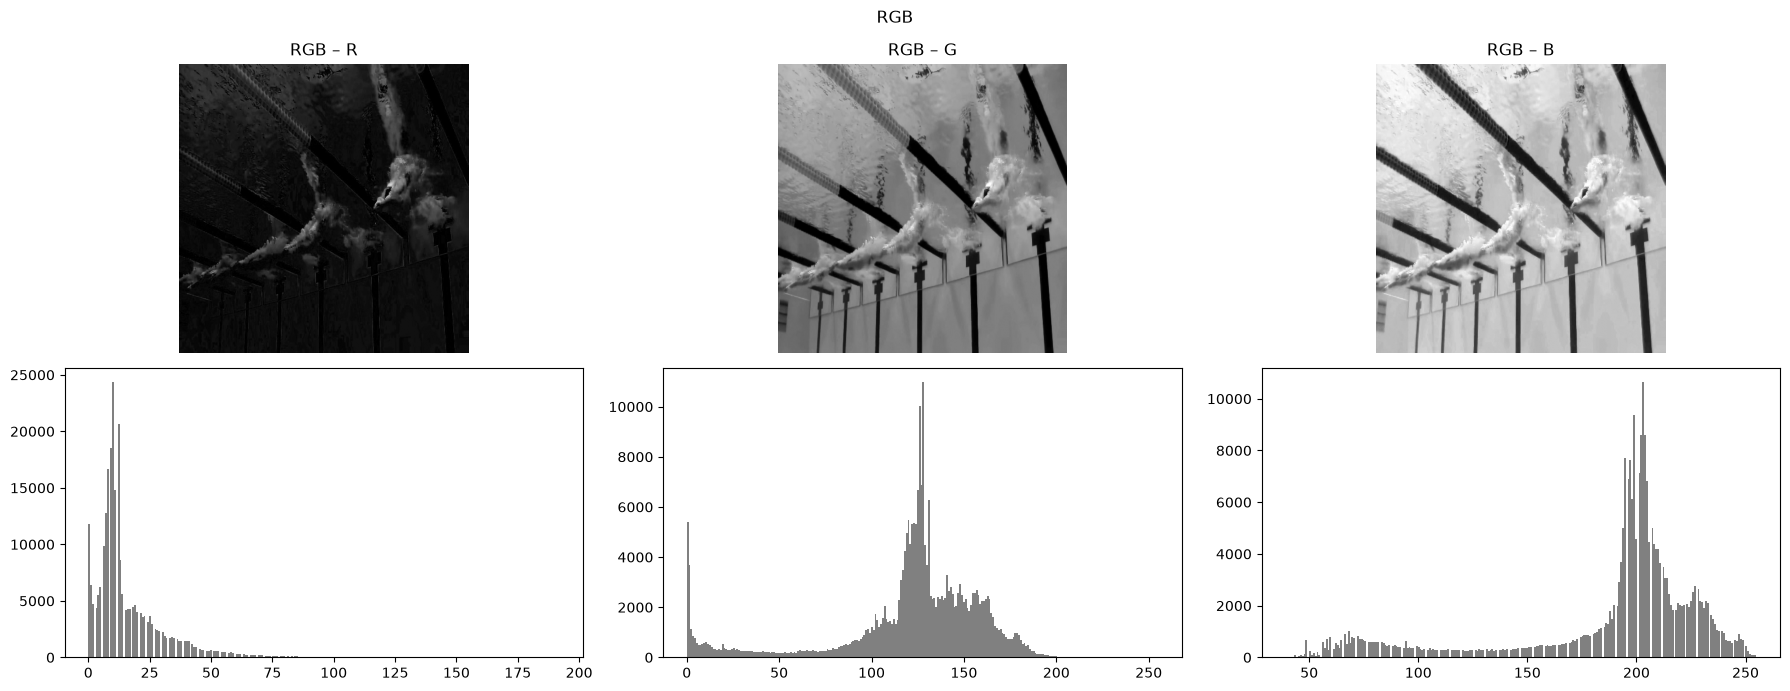

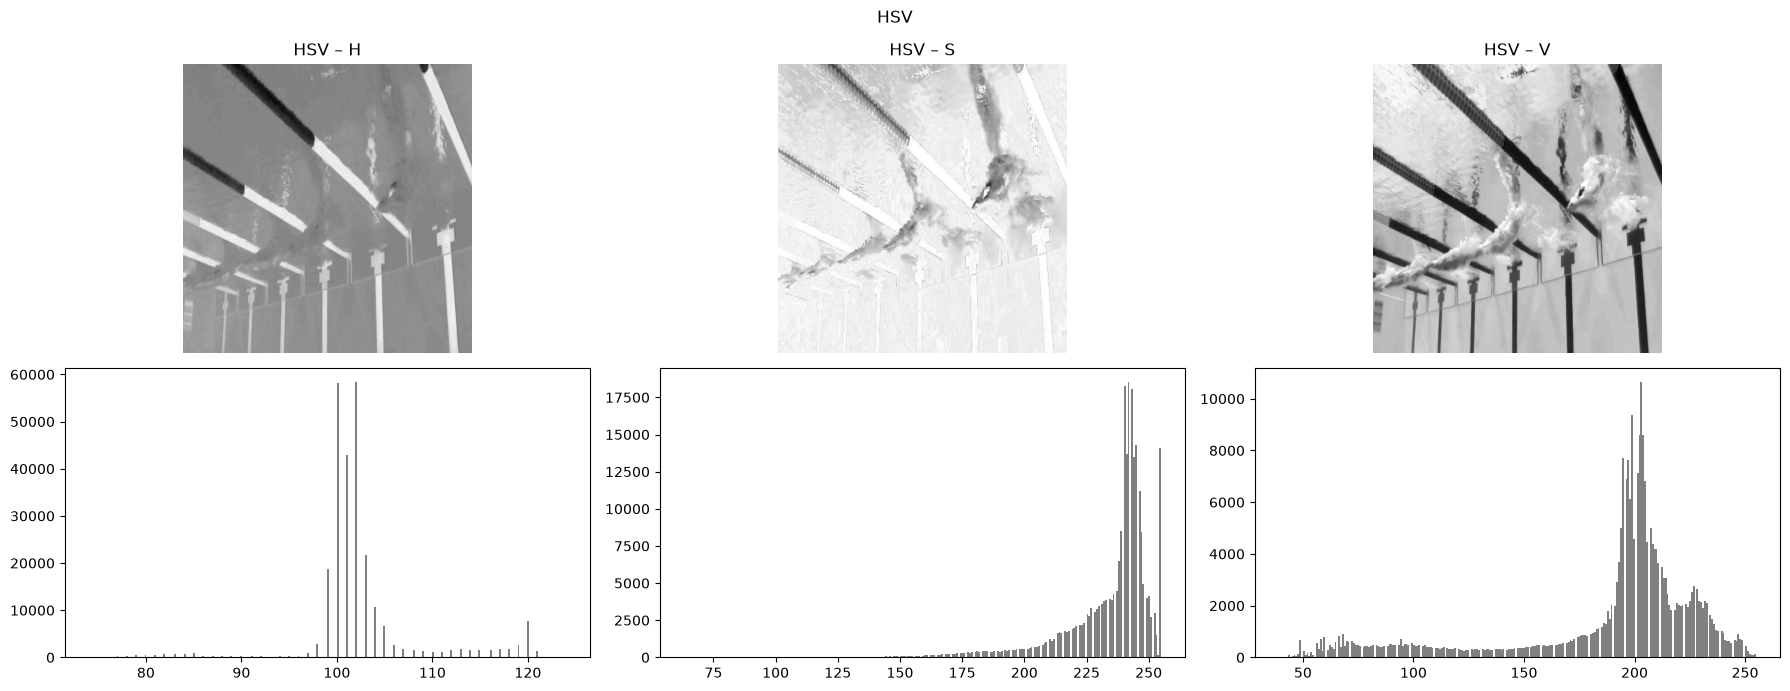

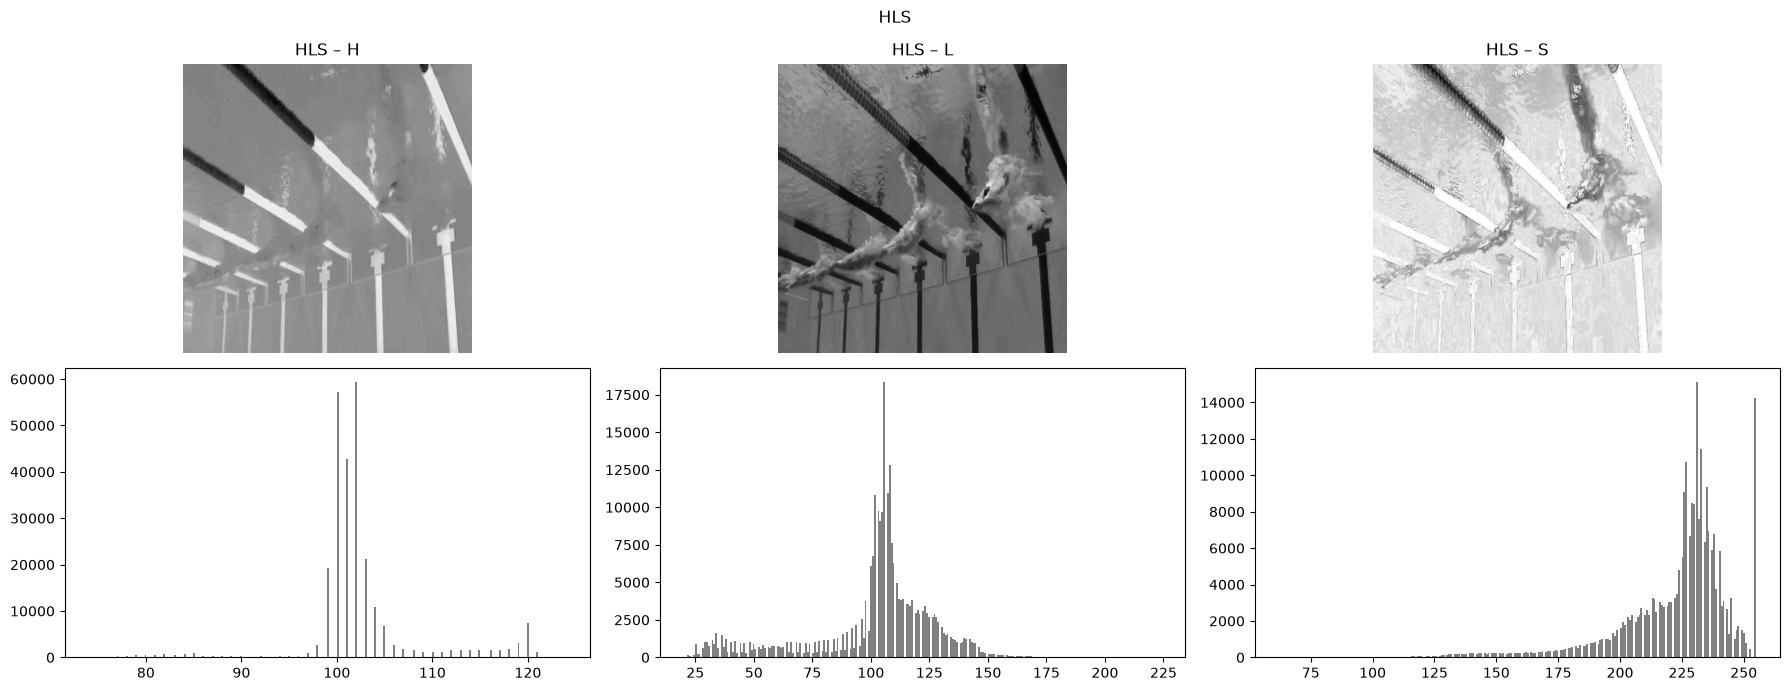

In [72]:
#LAB y YCrCb se ignoran porque no aportan nada.
espacios = {
    'RGB':   (image, ['R', 'G', 'B']),
    'HSV':   (cv2.cvtColor(image, cv2.COLOR_RGB2HSV), ['H', 'S', 'V']),
    'HLS':   (cv2.cvtColor(image, cv2.COLOR_RGB2HLS), ['H', 'L', 'S'])
}

for nombre, (im, canales) in espacios.items():
    fig, ax = plt.subplots(2, 3, figsize=(18, 7))
    for i, c in enumerate(canales):
        ax[0, i].imshow(im[..., i], cmap='gray'); ax[0, i].set_title(f'{nombre} – {c}'); ax[0, i].axis('off')
        ax[1, i].hist(im[..., i].ravel(), bins=256, color='gray')
    plt.suptitle(nombre); plt.tight_layout(); plt.show()

La mayoría de la imagen sigue siendo piscina, por lo tanto el histograma del agua debería concentrarse en una media. En esta toma aparece además el efecto del agua sobre la luz: el rojo se absorbe y todo se corre hacia el azul.


*   RGB: acá sí aporta más que en la vista superior.
    *   R: casi no hay rojo, todo queda entre 0 y 50. Lo poco que sobrevive viene de las burbujas blancas alrededor de los nadadores, por lo que R termina identificando a los nadadores.
    *   G: curiosamente discrimina gran parte de las corcheras, que quedan oscuras frente al agua.
    *   B: sigue cargado a la derecha por el color del agua.
*   HSV y HLS:
    *   H (tono/color): el pico es todavía más estrecho que en la vista superior, entre 100 y 104. Todo lo que no sea el centro no es piscina, tanto lo muy alto como lo muy bajo. Cerca de 120 están los tramos negros de las corcheras y las marcas T del fondo, y entre 78 y 90 está la corchera amarilla, que bajo el agua se ve verde. Los nadadores y las burbujas no se ven en H porque quedan teñidos del mismo azul del agua.
    *   S (HSV): diferencia a los nadadores, que se ven más oscuros que el agua porque tienen menos saturación.
    *   V (HSV): segmenta por completo las corcheras, que tienen un valor muy puro y oscuro, entre 50 y 100, frente al agua que queda cerca de 200. Las burbujas quedan del otro lado, cerca de 230. Las marcas T también son oscuras, así que para separarlas de las corcheras se necesita H.
    *   L (HLS): se comporta igual que V.

Con esto, en esta vista cada canal se especializa: H separa el fondo, S y R encuentran a los nadadores, y V (o L) segmenta las corcheras.

### Separación del fondo

Según el histograma de HSV, el tono de la piscina puede encontrarse entre 80 y 110. Se utiliza este valor inicial y a partir de ahí se experimenta.

Además es importante mencionar que los tonos principales en la imagen son:



*   Corcheras: 85 (amarilla) y 120 (azul)
*   Piscina agua: 98 - 100 aprox
*   Lineas azules guía: 115 - 120

Esto ya nos da un diagnostico. El agua se segmentara bien, las corcheras y líneas de guía no.



In [73]:
hsv = (cv2.cvtColor(image, cv2.COLOR_RGB2HSV))

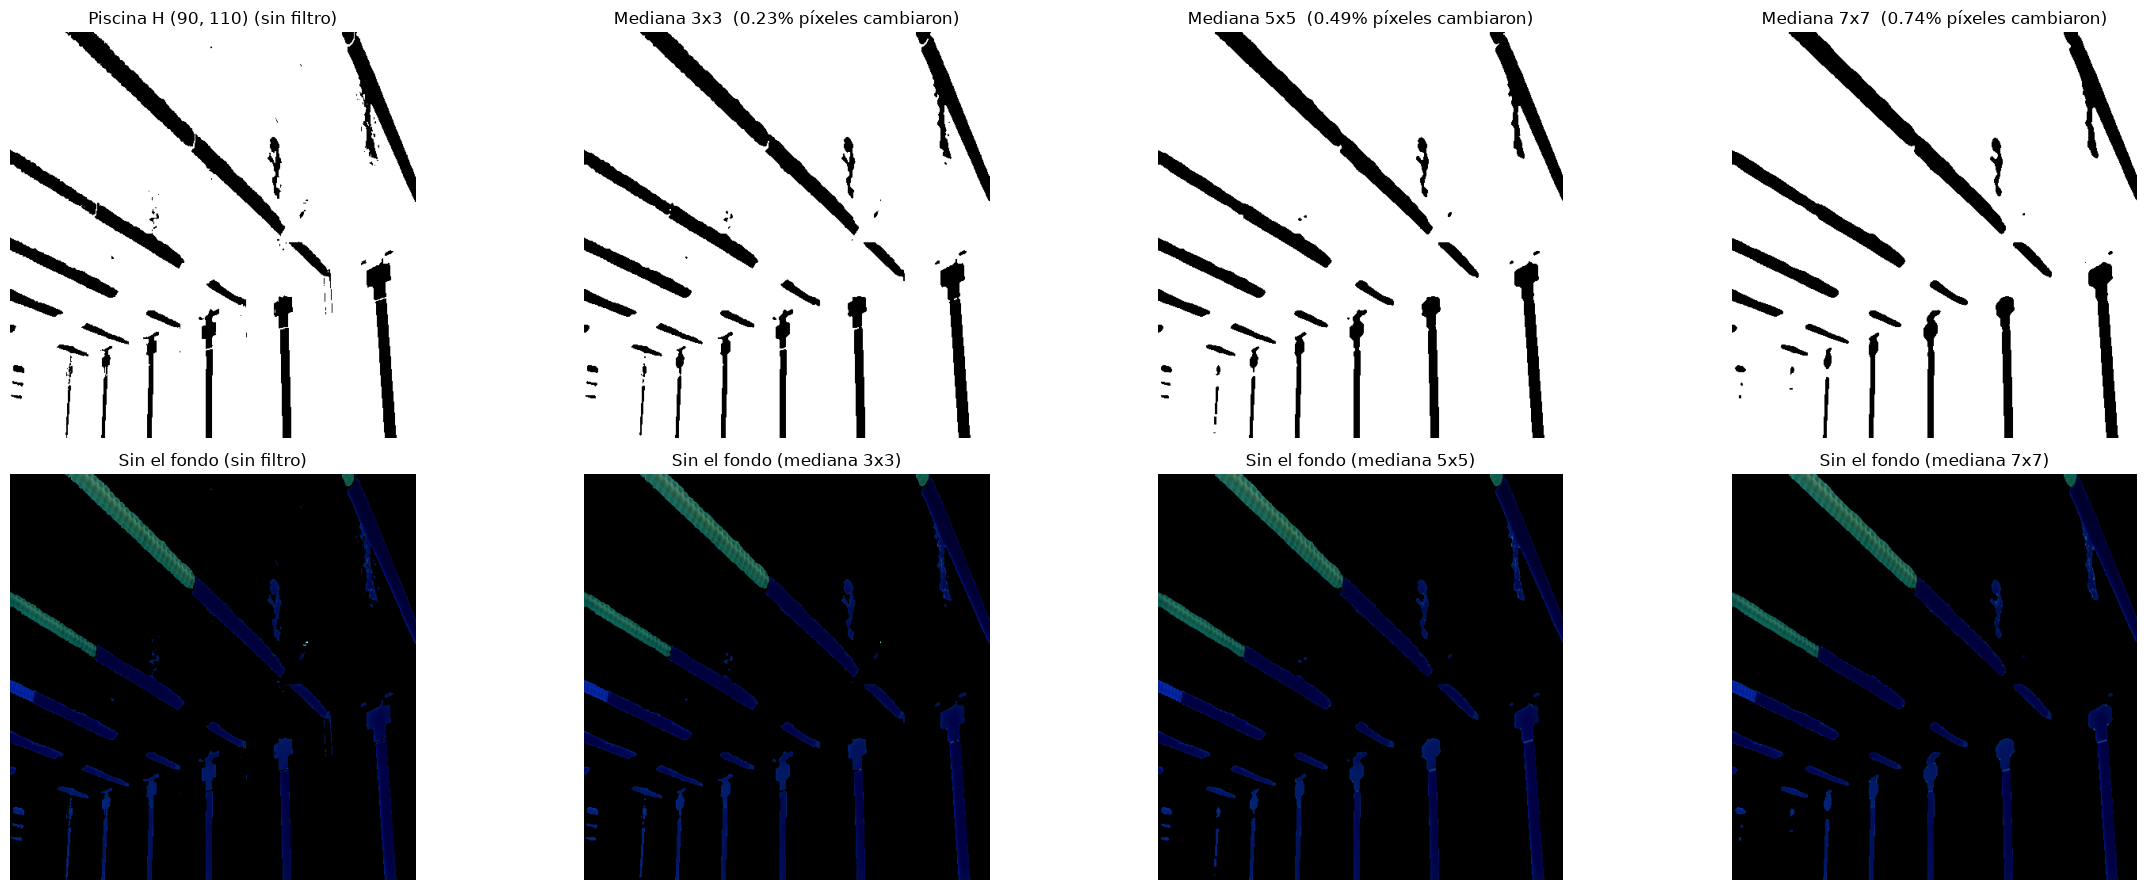

In [74]:
H_PISCINA = (90, 110)
piscina = cv2.inRange(hsv[..., 0], *H_PISCINA)

tamanos = [3, 5, 7]
piscina_filtrada = {k: cv2.medianBlur(piscina, k) for k in tamanos}

fig, ax = plt.subplots(2, 4, figsize=(24, 9))
ax[0, 0].imshow(piscina, cmap='gray'); ax[0, 0].set_title(f'Piscina H {H_PISCINA} (sin filtro)')
ax[1, 0].imshow(cv2.bitwise_and(image, image, mask=255 - piscina)); ax[1, 0].set_title('Sin el fondo (sin filtro)')
for i, k in enumerate(tamanos, start=1):
    m = piscina_filtrada[k]
    cambiados = (m != piscina).mean() * 100
    ax[0, i].imshow(m, cmap='gray'); ax[0, i].set_title(f'Mediana {k}x{k}  ({cambiados:.2f}% píxeles cambiaron)')
    ax[1, i].imshow(cv2.bitwise_and(image, image, mask=255 - m)); ax[1, i].set_title(f'Sin el fondo (mediana {k}x{k})')
for a in ax.ravel(): a.axis('off')
plt.tight_layout(); plt.show()

Con la máscara de piscina fija en H 90-110 se prueba una mediana cuadrada de 3x3, 5x5 y 7x7. La idea es cerrar huecos y puntos del fondo, sin volver a tocar el tono.

*   La de 3x3 limpia puntos sueltos y casi no mueve el borde.
*   La de 5x5 cierra más huecos. La de 7x7 cierra todavía más, pero la ventana es igual de ancha que de alta y se come bordes en todas las direcciones.

La mediana sola no sigue la dirección de las líneas de la piscina. Eso se prueba en la celda siguiente, en vertical y en horizontal.

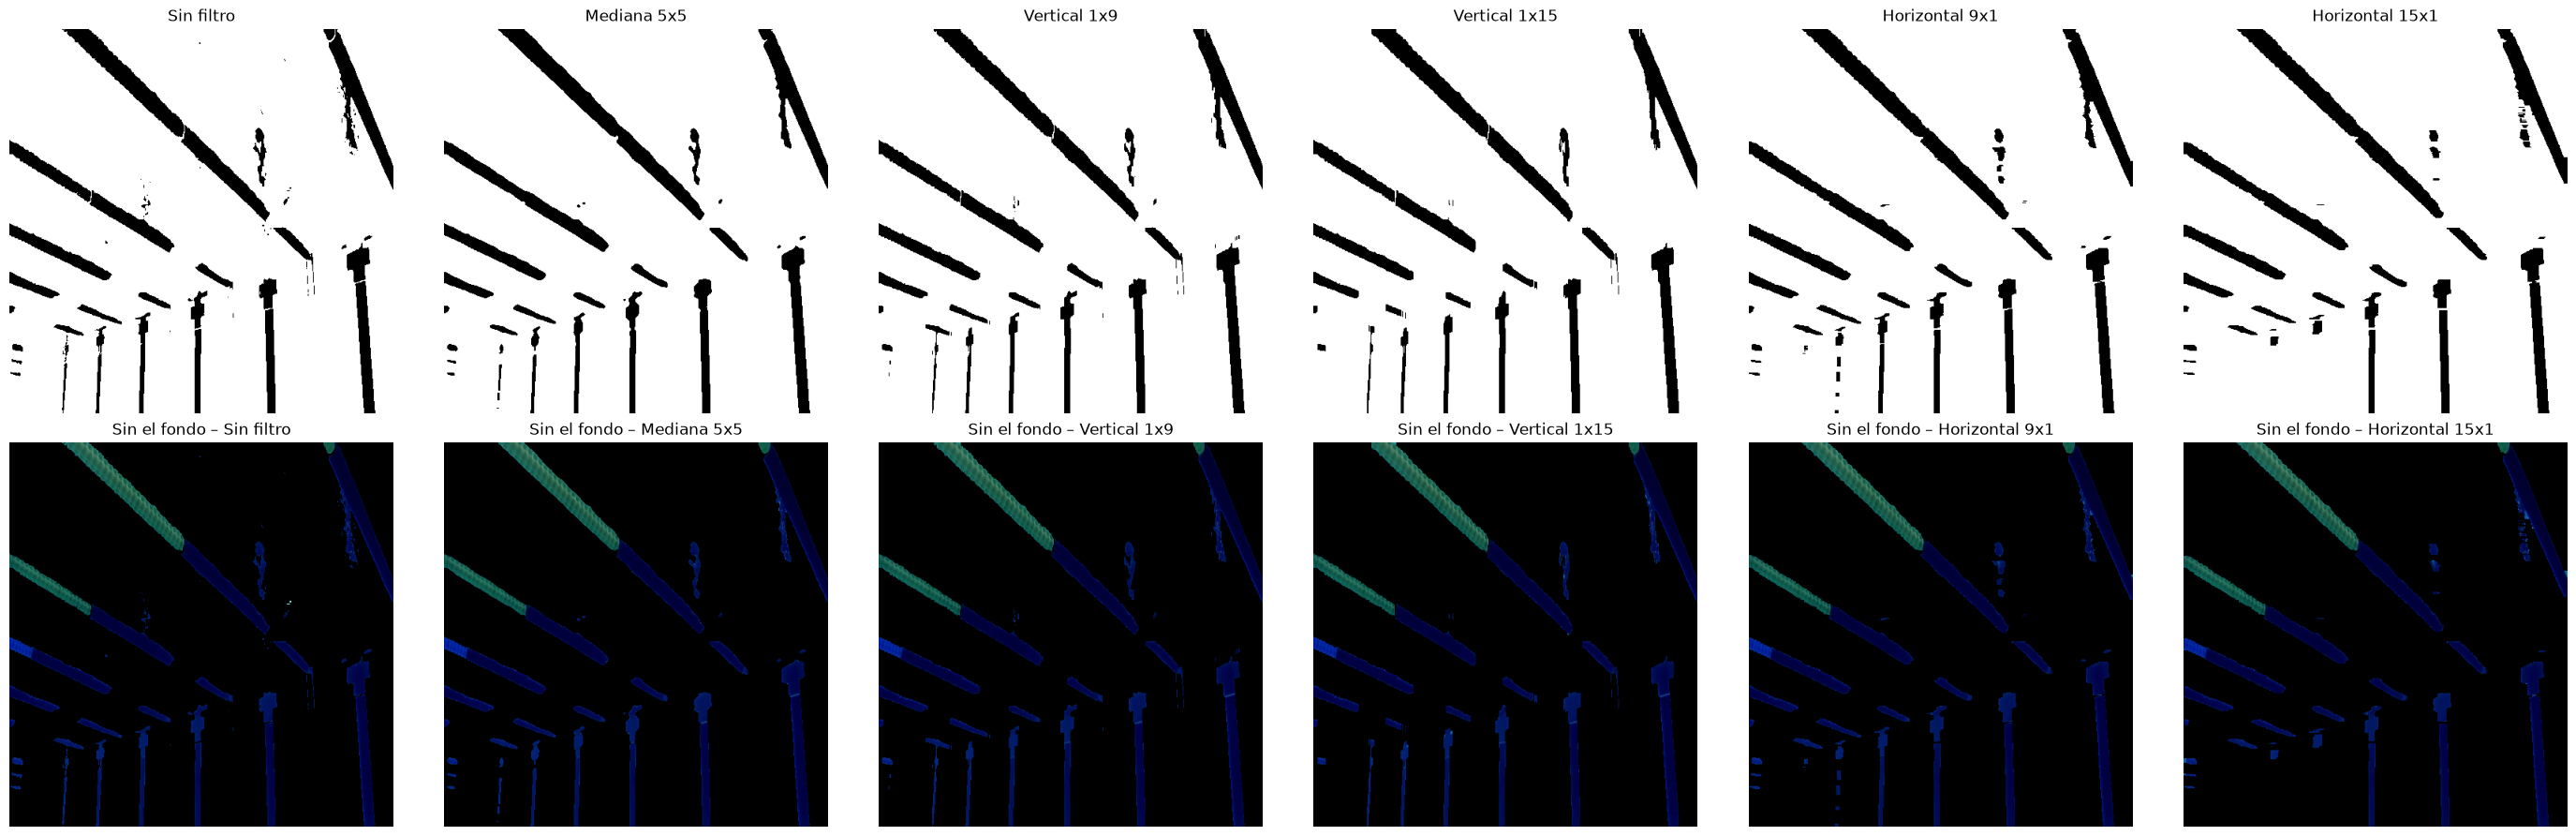

In [75]:
piscina = cv2.inRange(hsv[..., 0], 90, 110)

def votacion(mascara, ancho, alto):
    """Promedio en una ventana ancho x alto y umbral 0.5 = votación de mayoría."""
    return ((cv2.blur(mascara, (ancho, alto)) > 127) * 255).astype(np.uint8)

versiones = {
    'Sin filtro':       piscina,
    'Mediana 5x5':      cv2.medianBlur(piscina, 5),
    'Vertical 1x9':     votacion(piscina, 1, 9),
    'Vertical 1x15':    votacion(piscina, 1, 15),
    'Horizontal 9x1':   votacion(piscina, 9, 1),
    'Horizontal 15x1':  votacion(piscina, 15, 1),
}

fig, ax = plt.subplots(2, len(versiones), figsize=(28, 9))
for i, (nombre, m) in enumerate(versiones.items()):
    ax[0, i].imshow(m, cmap='gray'); ax[0, i].set_title(nombre)
    ax[1, i].imshow(cv2.bitwise_and(image, image, mask=255 - m)); ax[1, i].set_title(f'Sin el fondo – {nombre}')
for a in ax.ravel(): a.axis('off')
plt.tight_layout(); plt.show()

La mediana cuadrada mira para todos lados. La ventana vertical solo vota hacia arriba y hacia abajo, y la horizontal solo hacia los lados. Un píxel queda como piscina si la mayoría de esa ventana también es piscina.

*   La vertical 1x9 deja más huecos que la 1x15. La 1x15 alarga el fondo en la dirección perpendicular al piso, que es como se ven las líneas guía en esta toma.
*   La horizontal 9x1 y 15x1 cierran cortes de izquierda a derecha. Sirve si la línea corre acostada, y borra menos lo que es alto y delgado.
*   Ninguna de las dos quita las líneas guía: esas no caen en H 90-110, así que nunca entran en esta máscara.

### Por qué H, S y V y no solo H

En esta vista el tono no alcanza para separar el agua. La piel de los nadadores cae en H 91 a 105 y la espuma en H 99, o sea dentro del mismo rango del agua. Si la máscara se arma solo con H, los nadadores entran al fondo y se pierden.

La piel se separa por brillo. Su V va de 97 a 138, mientras el agua está entre 180 y 235. La espuma se separa por saturación: tiene S cercano a 108 frente a 240 del agua, aunque esto no se cumple en todos los cuadros.

El problema es que el V del agua no es el mismo en todos los cuadros. Va de 180 a 235 según la toma, así que un número fijo que sirva en un cuadro deja pasar piel en otro. Por eso el umbral de V se calcula por imagen: se toma la mediana de V de los píxeles que pasaron el filtro de tono y el umbral es el 75 por ciento de ese valor.

Ese umbral sigue siendo global para toda la imagen. Lo que cambia es de dónde sale el número, que es una estadística del histograma de la propia imagen y no una constante escrita a mano. No es un umbral local por vecindad.

La limpieza final es una mediana cuadrada. En la vista superior se usó una ventana vertical porque los carriles corren en una sola dirección, pero acá las corcheras se ven en diagonal o en horizontal según la toma y no hay dirección que privilegiar.

Temas del curso que respaldan esto: 7.2.2 Clipping and Thresholding para la umbralización en H, S y V; 7.2.3 Histogram Modeling para la mediana de V; 7.3.3 Median Filtering para la limpieza; y la imagen multiespectral en HSV del PDF de formación de la imagen.

In [ ]:
def fondo_ilp(img_rgb, h_agua=(90, 110), s_min=150, factor_v=0.75, k_mediana=5):
    """Máscara del agua para la vista dentro de la piscina (255 = agua)."""
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    H, S, V = cv2.split(hsv)

    tono = cv2.inRange(H, *h_agua)

    v_ref = np.median(V[tono > 0])
    v_min = int(factor_v * v_ref)

    agua = cv2.inRange(hsv, (h_agua[0], s_min, v_min), (h_agua[1], 255, 255))

    agua = cv2.medianBlur(agua, k_mediana)
    return agua, v_ref, v_min

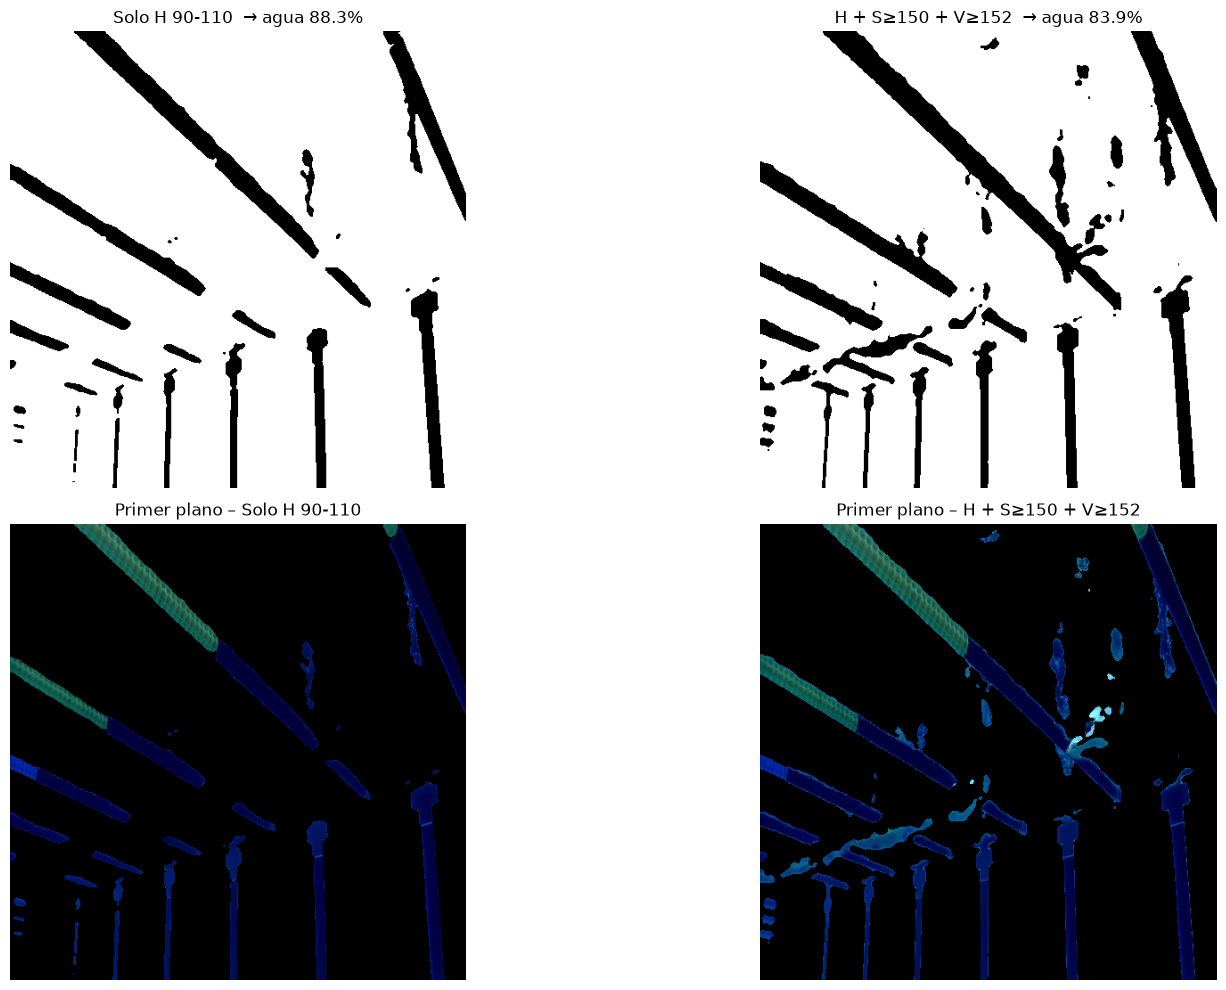

V de referencia del agua: 203  → umbral V: 152


In [77]:
agua_h = cv2.medianBlur(cv2.inRange(hsv[..., 0], 90, 110), 5)
agua, v_ref, v_min = fondo_ilp(image)

versiones = {'Solo H 90-110': agua_h, f'H + S≥150 + V≥{v_min}': agua}

fig, ax = plt.subplots(2, 2, figsize=(18, 10))
for i, (nombre, m) in enumerate(versiones.items()):
    ax[0, i].imshow(m, cmap='gray'); ax[0, i].set_title(f'{nombre}  → agua {m.mean()/2.55:.1f}%')
    ax[1, i].imshow(cv2.bitwise_and(image, image, mask=255 - m)); ax[1, i].set_title(f'Primer plano – {nombre}')
for a in ax.ravel(): a.axis('off')
plt.tight_layout(); plt.show()
print(f'V de referencia del agua: {v_ref:.0f}  → umbral V: {v_min}')

El fondo de esta vista no se puede ignorar solo con el tono, a diferencia de la vista superior. Hacen falta los tres canales.

El tono da los candidatos, H entre 90 y 110. La saturación saca la espuma, con S mayor o igual a 150. El brillo saca la piel, los trajes y las corcheras, con un umbral de V que no es fijo: sale de la mediana de V del agua de la propia imagen, tomando el 75 por ciento de ese valor. En el ejemplo el agua tiene V de referencia 203 y el umbral queda en 152.

La limpieza es una mediana 5x5, cuadrada. En la vista superior se usó una ventana vertical porque los carriles corren en una sola dirección; acá las corcheras se ven en diagonal o en horizontal según la toma.

Las líneas guía están en H 115 a 120, fuera del agua, así que esta máscara no las quita. Sumar ese rango al fondo las ignora también, con el riesgo de llevarse alguna corchera azul, que está cerca de 120.

Los recuadros de la transmisión no se pueden quitar por color y se tapan con dos ROI fijas.